# Membership EDA: 가격과 동시시청자수의 관계

1. 가격(`amount`)만으로 동시시청자수(`concurrent_streams`)를 설명할 수 있는가
2. `product_cd`를 함께 보면 관계가 더 명확해지는가
3. `concurrent_streams` 결측은 무작위 결측인가, 아니면 특정 상품에 집중된 구조적 결측인가


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")
sns.set_theme(style="whitegrid")

membership = pd.read_excel("../Dataset/Membership.xlsx")

analysis_cols = [
    "product_cd",
    "amount",
    "billing_method",
    "payment_device",
    "is_user_verified",
    "concurrent_streams",
]


def unique_sorted(series):
    return sorted(series.dropna().unique().tolist())


def unique_int_sorted(series):
    return sorted([int(x) for x in series.dropna().unique().tolist()])


membership[analysis_cols].head()


,product_cd,amount,billing_method,payment_device,is_user_verified,concurrent_streams
0,pk_1489,100.00,134,pc,Y,4.0
1,pk_1487,100.00,190,pc,Y,1.0
2,pk_1487,100.00,132,android,NaN,1.0
3,pk_1508,9.99,140,ios,N,1.0
4,pk_1488,100.00,180,android,N,2.0


> 1. 기본 점검  

먼저 분석에 사용할 핵심 변수만 확인한다.

`amount`와 `concurrent_streams`만 보면 관계가 단순해 보일 수 있으므로, 이후에는 `product_cd`와 결제 관련 변수까지 같이 본다.


In [3]:
basic_summary = pd.DataFrame({
    "rows": [len(membership)],
    "product_cd_nunique": [membership["product_cd"].nunique()],
    "amount_nunique": [membership["amount"].nunique()],
    "billing_method_nunique": [membership["billing_method"].nunique()],
    "payment_device_nunique": [membership["payment_device"].nunique()],
    "concurrent_streams_missing": [membership["concurrent_streams"].isna().sum()],
})

display(basic_summary)
display(membership[analysis_cols].sample(10, random_state=42).sort_values(["product_cd", "amount"]))


,rows,product_cd_nunique,amount_nunique,billing_method_nunique,payment_device_nunique,concurrent_streams_missing
0,18183,53,32,10,10,70


,product_cd,amount,billing_method,payment_device,is_user_verified,concurrent_streams
15557,pk_1136,10.99,140,ios,N,1.0
8492,pk_1487,100.00,190,mobile,Y,1.0
14449,pk_1487,7900.00,190,android,N,1.0
9737,pk_1488,100.00,132,android,Y,2.0
1034,pk_1488,100.00,180,mobile,Y,2.0
15855,pk_1489,100.00,134,pc,Y,4.0
13904,pk_2025,100.00,151,android,Y,1.0
960,pk_2025,100.00,151,android,Y,1.0
14119,pk_2025,7900.00,151,android,Y,1.0
8522,pk_2027,100.00,151,android,Y,4.0


> 2. 가격만 보면 관계가 깔끔한가  

먼저 `amount` 기준으로 어떤 `payment_device`, `product_cd`, `concurrent_streams`가 묶이는지 확인.  
이 단계의 핵심은 가격이 단독으로 동시시청자수를 결정하는지 보는 것.  
결론: 가격만으로는 동시시청자수가 일대일로 결정되지 않는다. amount=100.00은 concurrent_streams 1, 2, 4 모두에 연결됨 (8개 상품이 같은 가격 공유)


In [4]:
amount_summary = (
    membership.groupby("amount")
    .agg(
        rows=("amount", "size"),
        product_count=("product_cd", "nunique"),
        product_list=("product_cd", unique_sorted),
        payment_device_list=("payment_device", unique_sorted),
        billing_method_list=("billing_method", unique_sorted),
        concurrent_list=("concurrent_streams", unique_int_sorted),
        concurrent_nunique=("concurrent_streams", lambda s: s.dropna().nunique()),
        missing_count=("concurrent_streams", lambda s: s.isna().sum()),
    )
    .reset_index()
    .sort_values("amount")
)

ambiguous_amounts = amount_summary[amount_summary["concurrent_nunique"] > 1].copy()

display(
    amount_summary[
        [
            "amount",
            "rows",
            "product_count",
            "payment_device_list",
            "concurrent_list",
            "concurrent_nunique",
            "missing_count",
        ]
    ]
)

display(ambiguous_amounts[["amount", "product_count", "product_list", "concurrent_list"]])


,amount,rows,product_count,payment_device_list,concurrent_list,concurrent_nunique,missing_count
0,7.69,1,1,[ios],[],0,1
1,9.89,6,1,[ios],[1],1,0
2,9.99,2130,1,[ios],[1],1,0
3,10.99,89,4,[ios],[1],1,51
4,13.19,6,3,[ios],[1],1,4
5,13.49,614,1,[ios],[2],1,0
6,14.29,18,3,[ios],"[1, 2]",2,0
7,16.49,220,4,[ios],"[1, 3, 4]",3,2
8,17.59,3,3,[ios],"[1, 2]",2,1
9,20.49,1,1,[ios],[2],1,0


,amount,product_count,product_list,concurrent_list
6,14.29,3,"[pk_1139, pk_142, pk_845]","[1, 2]"
7,16.49,4,"[pk_1142, pk_1507, pk_1509, pk_847]","[1, 3, 4]"
8,17.59,3,"[pk_1148, pk_1154, pk_848]","[1, 2]"
10,21.99,2,"[pk_1143, pk_849]","[1, 3]"
12,27.49,2,"[pk_1160, pk_1166]","[2, 3]"
14,100.00,8,"[pk_1487, pk_1488, pk_1489, pk_2005, pk_2025, ...","[1, 2, 4]"
26,10900.00,3,"[pk_123, pk_1488, pk_2026]","[1, 2]"


왼쪽 산점도: 가격-동시시청자수 쌍의 실제 분포 (버블 크기 = 행 수)  
오른쪽 바차트: 같은 가격에서 여러 동시시청자수가 나타나는 가격대 7개

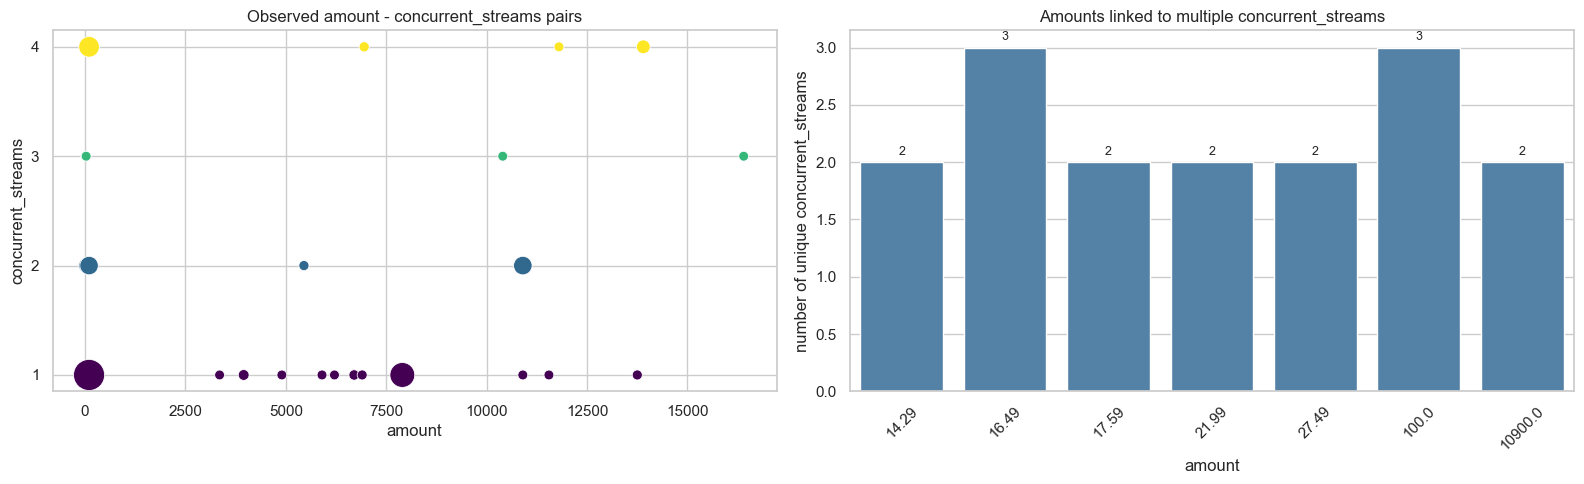

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

amount_pair_df = (
    membership.dropna(subset=["concurrent_streams"])
    .groupby(["amount", "concurrent_streams"])
    .size()
    .reset_index(name="rows")
)

sns.scatterplot(
    data=amount_pair_df,
    x="amount",
    y="concurrent_streams",
    size="rows",
    sizes=(50, 500),
    hue="concurrent_streams",
    palette="viridis",
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Observed amount - concurrent_streams pairs")
axes[0].set_ylabel("concurrent_streams")
axes[0].set_yticks([1, 2, 3, 4])

sns.barplot(
    data=ambiguous_amounts,
    x="amount",
    y="concurrent_nunique",
    color="steelblue",
    ax=axes[1],
)
axes[1].set_title("Amounts linked to multiple concurrent_streams")
axes[1].set_ylabel("number of unique concurrent_streams")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)

plt.tight_layout()
plt.show()


> 3. `product_cd`를 함께 보면 관계가 훨씬 선명해진다  

다음 단계에서는 가격보다 상품 코드가 더 직접적으로 `concurrent_streams`를 설명하는지 확인.  
만약 대부분의 `product_cd`가 하나의 `concurrent_streams`에만 연결된다면, 동시시청자수는 가격 속성이라기보다 상품 속성에 가깝다고 볼 수 있다.  
결론: 상품코드 기준으로 보면 동시시청자수가 거의 완벽하게 1:1로 대응된다.  


In [6]:
product_summary = (
    membership.groupby("product_cd")
    .agg(
        rows=("product_cd", "size"),
        amount_nunique=("amount", "nunique"),
        amount_list=("amount", unique_sorted),
        concurrent_nunique=("concurrent_streams", lambda s: s.dropna().nunique()),
        concurrent_list=("concurrent_streams", unique_int_sorted),
        missing_count=("concurrent_streams", lambda s: s.isna().sum()),
        missing_rate=("concurrent_streams", lambda s: round(s.isna().mean() * 100, 2)),
    )
    .reset_index()
    .sort_values(["rows", "product_cd"], ascending=[False, True])
)

product_rule_summary = pd.DataFrame({
    "total_products": [product_summary["product_cd"].nunique()],
    "products_with_one_stream": [(product_summary["concurrent_nunique"] == 1).sum()],
    "products_with_only_missing": [(product_summary["concurrent_nunique"] == 0).sum()],
    "products_with_multiple_streams": [(product_summary["concurrent_nunique"] > 1).sum()],
})

display(product_rule_summary)
display(product_summary.head(15))


,total_products,products_with_one_stream,products_with_only_missing,products_with_multiple_streams
0,53,45,8,0


,product_cd,rows,amount_nunique,amount_list,concurrent_nunique,concurrent_list,missing_count,missing_rate
27,pk_1487,6693,3,"[100.0, 3950.0, 7900.0]",1,[1],0,0.0
28,pk_1488,2546,3,"[100.0, 5450.0, 10900.0]",1,[2],0,0.0
41,pk_2025,2237,3,"[100.0, 3950.0, 7900.0]",1,[1],0,0.0
29,pk_1489,2191,3,"[100.0, 6950.0, 13900.0]",1,[4],0,0.0
33,pk_1508,2130,1,[9.99],1,[1],0,0.0
42,pk_2026,632,3,"[100.0, 5450.0, 10900.0]",1,[2],0,0.0
31,pk_1506,614,1,[13.49],1,[2],0,0.0
43,pk_2027,547,3,"[100.0, 6950.0, 13900.0]",1,[4],0,0.0
32,pk_1507,208,1,[16.49],1,[4],0,0.0
39,pk_2005,115,3,"[100.0, 3350.0, 6700.0]",1,[1],0,0.0


히트맵으로 상위 12개 상품의 concurrent_streams 분포를 보여줌 → 각 상품이 특정 값에만 집중됨이 한눈에 보임.

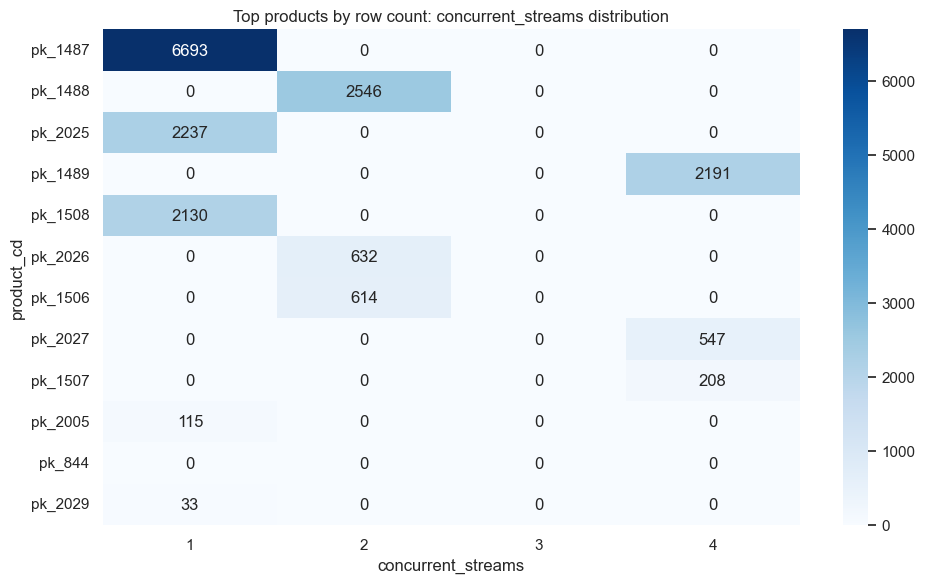

In [7]:
top_products = product_summary.head(12)["product_cd"].tolist()

product_stream_ct = pd.crosstab(membership["product_cd"], membership["concurrent_streams"]).reindex(top_products).fillna(0)
product_stream_ct.columns = [int(col) for col in product_stream_ct.columns]

plt.figure(figsize=(10, 6))
sns.heatmap(product_stream_ct, annot=True, fmt=".0f", cmap="Blues")
plt.title("Top products by row count: concurrent_streams distribution")
plt.xlabel("concurrent_streams")
plt.ylabel("product_cd")
plt.tight_layout()
plt.show()


> 4. `concurrent_streams` 결측은 무작위인가  

이제 결측 집단만 따로 떼어 본다.

결측이 일부 상품에 몰려 있다면 단순한 누락이 아니라 상품 설계, 적재 규칙, 외부 결제 경로 문제일 가능성이 높다.

결측이 무작위로 흩어진 게 아니라 특정 상품(pk_844)에 73%가 집중 → 구조적 결측(MNAR)일 가능성이 높음  
특히 pk_844는 billing_method=140 + payment_device=iOS 조합으로 고정되어 있어, iOS 결제 경로에서 concurrent_streams가 적재되지 않는 로직 버그일 가능성 제기   

In [8]:
only_conc_na = membership[membership["concurrent_streams"].isna()].copy()

missing_summary = (
    only_conc_na.groupby("product_cd")
    .agg(
        rows=("product_cd", "size"),
        amount_list=("amount", unique_sorted),
        billing_method_list=("billing_method", unique_sorted),
        payment_device_list=("payment_device", unique_sorted),
        verified_list=("is_user_verified", unique_sorted),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

display(missing_summary)


,product_cd,rows,amount_list,billing_method_list,payment_device_list,verified_list
4,pk_844,51,[10.99],[140],[ios],"[N, Y]"
0,pk_118,6,[5900.0],"[131, 132]",[android],[Y]
5,pk_846,4,[13.19],[140],[ios],[N]
1,pk_119,4,[6900.0],[132],"[android, mobile, pc]",[Y]
6,pk_847,2,[16.49],[140],[ios],"[N, Y]"
2,pk_137,1,[7.69],[140],[ios],[N]
3,pk_328,1,[5900.0],[121],[smarttv],[]
7,pk_848,1,[17.59],[140],[ios],[N]


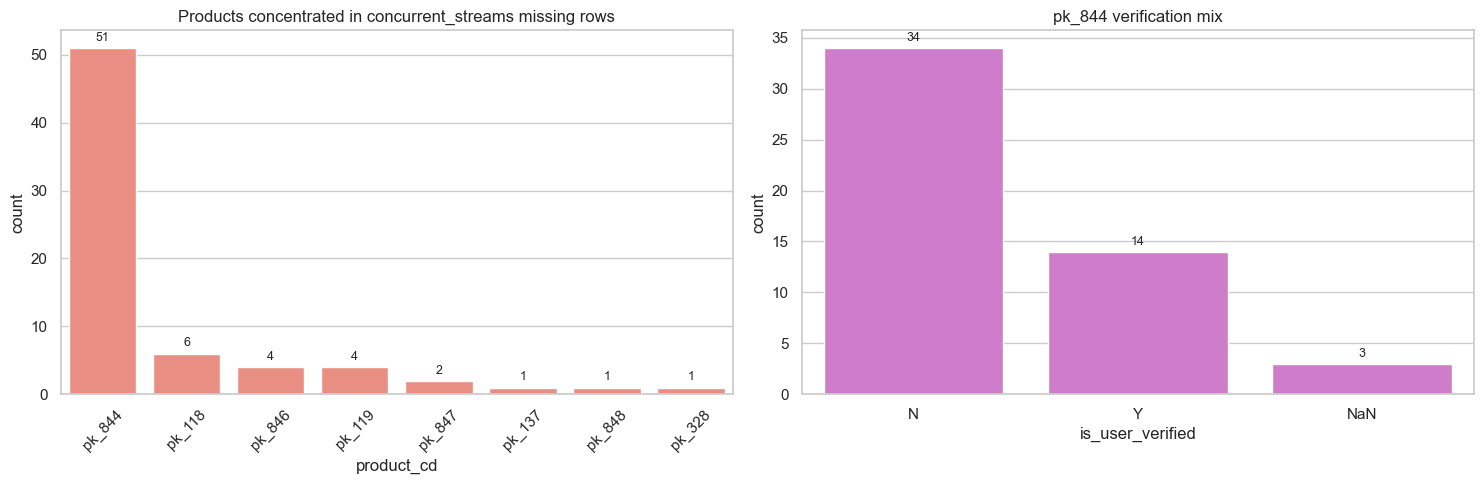

,product_cd,amount,billing_method,payment_device,is_user_verified,concurrent_streams
182,pk_844,10.99,140,ios,N,NaN
6679,pk_844,10.99,140,ios,Y,NaN
9699,pk_844,10.99,140,ios,NaN,NaN


In [9]:
count_df = only_conc_na["product_cd"].value_counts().reset_index()
count_df.columns = ["product_cd", "count"]

what_844 = membership[membership["product_cd"] == "pk_844"].copy()
what_844_profile = (
    what_844[
        [
            "product_cd",
            "amount",
            "billing_method",
            "payment_device",
            "is_user_verified",
            "concurrent_streams",
        ]
    ]
    .drop_duplicates()
    .sort_values(["amount", "billing_method"])
)

verify_count_844 = what_844["is_user_verified"].fillna("NaN").value_counts().reset_index()
verify_count_844.columns = ["is_user_verified", "count"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=count_df, x="product_cd", y="count", color="salmon", ax=axes[0])
axes[0].set_title("Products concentrated in concurrent_streams missing rows")
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

sns.barplot(data=verify_count_844, x="is_user_verified", y="count", color="orchid", ax=axes[1])
axes[1].set_title("pk_844 verification mix")
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)

plt.tight_layout()
plt.show()

display(what_844_profile)


## 5. 해석
- `amount`만으로는 `concurrent_streams`가 일대일로 정해지지 않는다.
- 반면 다수의 `product_cd`는 하나의 `concurrent_streams`에만 연결된다.
- 따라서 동시시청자수는 가격 속성이라기보다 상품 속성에 더 가깝다.
- `concurrent_streams` 결측은 `pk_844` 등 소수 상품에 집중되어 있어 무작위 결측으로 보기 어렵다.
- 특히 `pk_844`는 `amount=10.99`, `billing_method=140`, `payment_device=ios`로 고정되어 있어 구조적 결측 가능성이 높다.

## 6. 후속 확인 포인트
1. `pk_844`, `pk_846`, `pk_847`, `pk_848`이 실제로 어떤 요금제 묶음인지 상품 설명서를 통해 확인한다.
2. `billing_method=140`, `payment_device=ios` 경로에서 `concurrent_streams`가 누락되는 적재 로직이 있는지 확인한다.
3. 모델링 단계에서는 행 삭제보다 `concurrent_streams_missing_flag`를 먼저 두고 영향 비교를 진행한다.
